# SUR ajusté dynamiquement par filtre de Kalman

Implémente `models.kalman.HourlyKalmanSURModel` : un système SURE (24 équations horaires, coefficients "effet structurel moyen") dont chaque coefficient reçoit un facteur d'ajustement dynamique estimé par filtre de Kalman, comme décrit sur la slide de référence :

$$y_{t,h} = \beta_0 + \sum_j \big(\beta^{SUR}_{h,j}\,\beta^{Kalman}_{t,h,j}\big)\,x_{t,h,j} + \varepsilon_{t,h}$$

Mécanique du filtre reprise du notebook de référence ([`kalman_sur1h.ipynb`](https://github.com/PierreRobinSchnepf/Applied-Statistics-ENGIE/blob/main/notebooks/archive/kalman_sur1h.ipynb)) : cible en `log1p`, état = marche aléatoire initialisée à 1 (aucun ajustement au départ), mise à jour de Kalman standard. Écart assumé : ici l'intercept `beta_0` reste **fixe** (pas de facteur Kalman dessus), conformément à la formule ci-dessus — le notebook de référence, lui, glissait un intercept dynamique dans l'état.

**Important — ce que compare cette évaluation** : le Kalman prédit *un pas en avant* et assimile la vraie observation à chaque pas avant de passer au suivant (comme dans le notebook de référence). C'est donc un régime différent d'un OLS/SURE statique qui ne voit jamais la période de test. La comparaison pertinente ici est **SUR (facteurs figés à 1) vs. Kalman, évalués selon exactement le même protocole un-pas-en-avant** — pas les métriques du notebook `02_benchmark_ols_sure.ipynb`.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from models.dataset import load_dataset, build_hourly_equations, split_train_test, target_series
from models.kalman import HourlyKalmanSURModel
from models import metrics

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

df = load_dataset()
per_hour = build_hourly_equations(df)
train, test = split_train_test(per_hour, test_start="2025-01-01", test_end="2026-01-01")
print(f"train : {len(train[0])} jours | test : {len(test[0])} jours")

build_hourly_equations: panel équilibré sur 3055 jours (jours exclus par heure pour déséquilibre : {0: 10, 1: 14, 2: 5, 3: 13, 4: 14, 5: 14, 6: 14, 7: 14, 8: 14, 9: 14, 10: 14, 11: 14, 12: 14, 13: 14, 14: 14, 15: 14, 16: 14, 17: 14, 18: 14, 19: 14, 20: 14, 21: 13, 22: 13, 23: 13})
train : 2541 jours | test : 364 jours


In [2]:
model = HourlyKalmanSURModel().fit(train)

y_train, y_test = target_series(train), target_series(test)
# Prédictions train : trajectoire un-pas-en-avant réelle, calculée pendant fit()
# (partant de l'état initial =1) — pas un nouvel appel à predict(train), qui
# repartirait à tort de l'état déjà convergé en fin d'entraînement.
sur_train, kalman_train = model.train_sur_pred_, model.train_kalman_pred_
sur_test, kalman_test = model.predict(test)

## 1. Métriques (train / test, un pas en avant)

In [3]:
rows = []
for model_name, (train_p, test_p) in {"SUR (figé)": (sur_train, sur_test), "Kalman": (kalman_train, kalman_test)}.items():
    for split_name, y_true, pred in (("train", y_train, train_p), ("test", y_test, test_p)):
        rows.append({"modele": model_name, "split": split_name, **metrics.evaluate_overall(y_true, pred)})

summary = pd.DataFrame(rows).set_index(["modele", "split"])[["rmse", "mape", "mae", "n"]].round(2)
summary

rmse   mape      mae      n
modele     split                                 
SUR (figé) train   6965.01  12.20  5341.96  60984
           test   11648.05  29.45  9896.41   8736
Kalman     train   4299.96   7.48  3159.65  60984
           test    3741.70   7.35  2579.80   8736

## 2. Prédictions vs réel (2 semaines, test 2025)

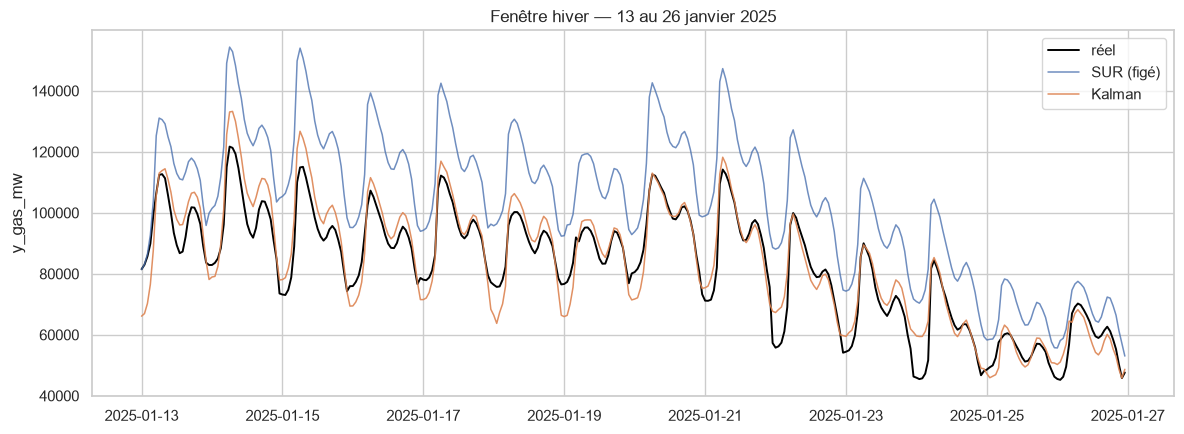

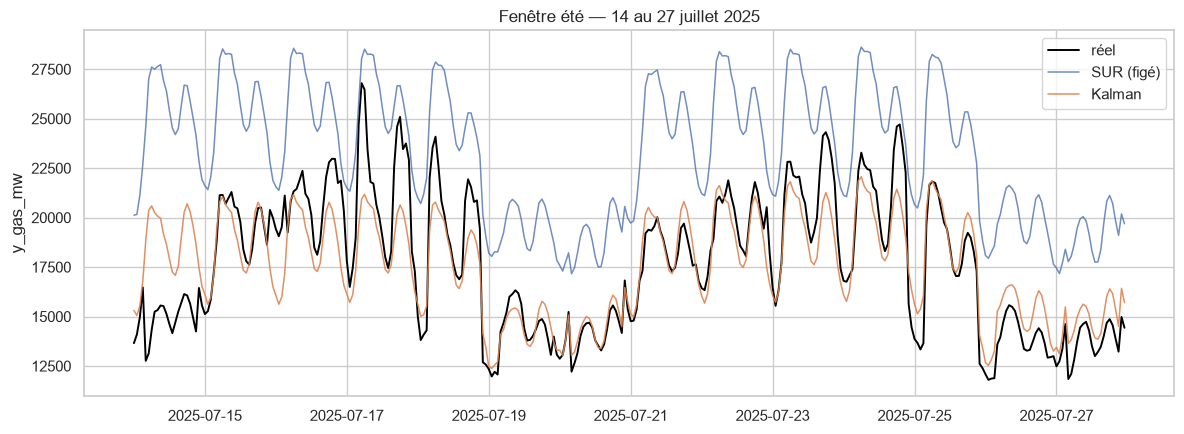

In [4]:
def plot_window(start, end, title):
    actual = metrics.combine_hourly(y_test).loc[start:end]
    sur_line = metrics.combine_hourly(sur_test).loc[start:end]
    kalman_line = metrics.combine_hourly(kalman_test).loc[start:end]

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(actual.index, actual.values, label="réel", color="black", linewidth=1.4)
    ax.plot(sur_line.index, sur_line.values, label="SUR (figé)", linewidth=1.1, alpha=0.8)
    ax.plot(kalman_line.index, kalman_line.values, label="Kalman", linewidth=1.1, alpha=0.9)
    ax.set_ylabel("y_gas_mw")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_window("2025-01-13", "2025-01-26", "Fenêtre hiver — 13 au 26 janvier 2025")
plot_window("2025-07-14", "2025-07-27", "Fenêtre été — 14 au 27 juillet 2025")

## 3. Erreur absolue cumulée (test 2025)

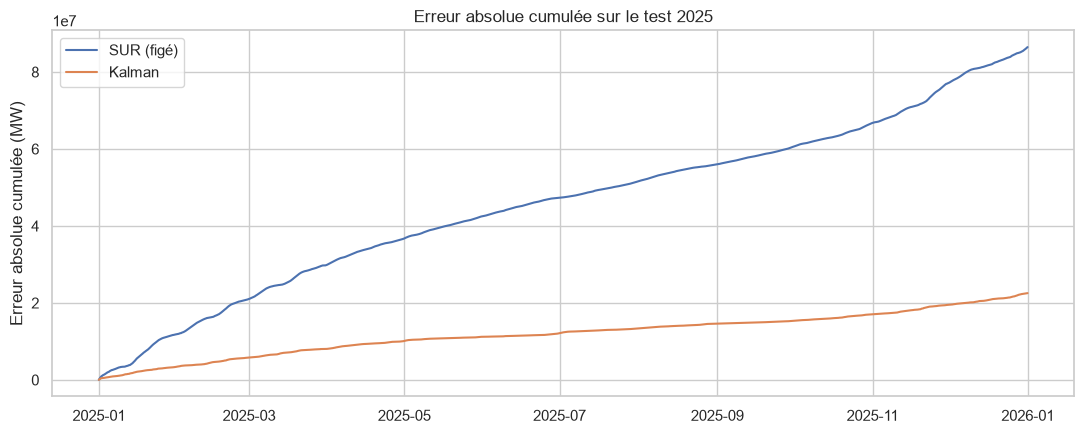

Erreur cumulée finale — SUR : 86,455,064 MW | Kalman : 22,537,152 MW


In [5]:
actual_full = metrics.combine_hourly(y_test)
sur_full = metrics.combine_hourly(sur_test)
kalman_full = metrics.combine_hourly(kalman_test)

sur_cum_err = (sur_full - actual_full).abs().cumsum()
kalman_cum_err = (kalman_full - actual_full).abs().cumsum()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(sur_cum_err.index, sur_cum_err.values, label="SUR (figé)")
ax.plot(kalman_cum_err.index, kalman_cum_err.values, label="Kalman")
ax.set_ylabel("Erreur absolue cumulée (MW)")
ax.set_title("Erreur absolue cumulée sur le test 2025")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Erreur cumulée finale — SUR : {sur_cum_err.iloc[-1]:,.0f} MW | Kalman : {kalman_cum_err.iloc[-1]:,.0f} MW")

## 4. Évolution des coefficients (facteurs d'échelle de Kalman, heure 7)
Trajectoire des facteurs d'ajustement $\beta^{Kalman}_{t,h,j}$ pour l'heure 7 (train puis test). Un facteur proche de 1 signifie "pas d'écart par rapport au SUR structurel" ; on trace les 3 variables du bloc thermique et `is_off_peak_period`.

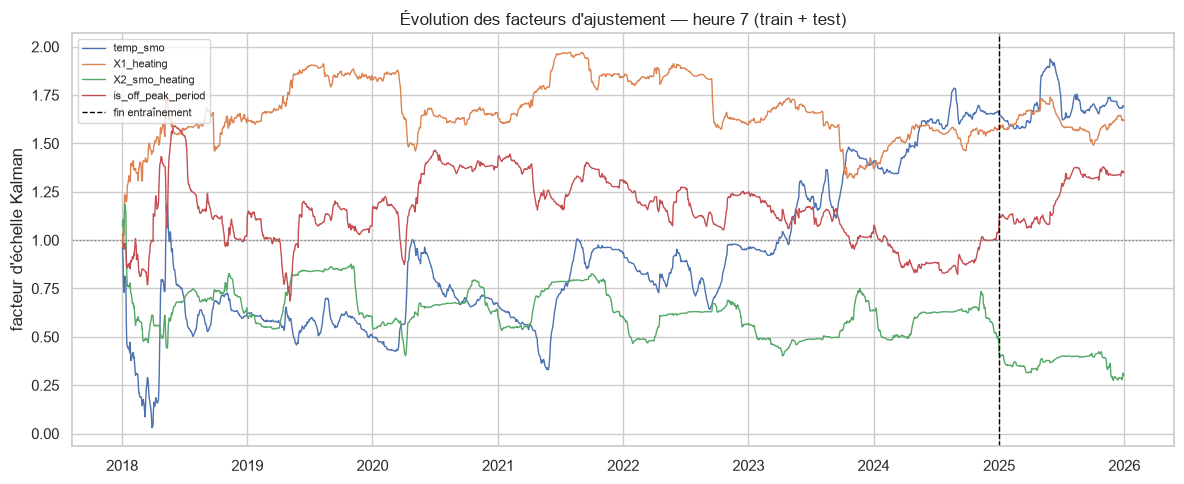

In [6]:
hour_to_inspect = 7
traj = model.full_beta_trajectory(hour_to_inspect)
cols_to_plot = ["temp_smo", "X1_heating", "X2_smo_heating", "is_off_peak_period"]
train_end_date = train[0].index.max()

fig, ax = plt.subplots(figsize=(12, 5))
for col in cols_to_plot:
    ax.plot(traj.index, traj[col].values, label=col, linewidth=1)
ax.axvline(pd.Timestamp(train_end_date), color="black", linestyle="--", linewidth=1, label="fin entraînement")
ax.axhline(1.0, color="grey", linestyle=":", linewidth=1)
ax.set_ylabel("facteur d'échelle Kalman")
ax.set_title(f"Évolution des facteurs d'ajustement — heure {hour_to_inspect} (train + test)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()